# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Michael Jolley

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

I0000 00:00:1791162538.595696 3145163 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791162542.632338 3145163 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791162553.715493 3145163 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
import os
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['non_fire_images', 'fire_images'] (0 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.


E0000 00:00:1791162633.352020 3145163 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

Images per class (whole dataset):
  fire_images       755
  non_fire_images   244


W0000 00:00:1791154752.935034 3111944 cpu_allocator_impl.cc:82] Allocation of 37740672 exceeds 10% of free system memory.
W0000 00:00:1791154753.315589 3111944 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1791154753.567410 3111944 cpu_allocator_impl.cc:82] Allocation of 11520000 exceeds 10% of free system memory.
W0000 00:00:1791154753.647308 3111944 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1791154754.161443 3111944 cpu_allocator_impl.cc:82] Allocation of 27796041 exceeds 10% of free system memory.



Train: {'fire_images': '538 (77%)', 'non_fire_images': '162 (23%)'}
Val:   {'fire_images': '96 (69%)', 'non_fire_images': '43 (31%)'}
Test:  {'fire_images': '117 (73%)', 'non_fire_images': '43 (27%)'}
Test (2nd pass): {'fire_images': '109 (68%)', 'non_fire_images': '51 (32%)'}

Most common original sizes (first 100 per class): [((1920, 1080), 6), ((1280, 720), 6), ((600, 400), 5), ((1200, 800), 4), ((1100, 619), 3)]


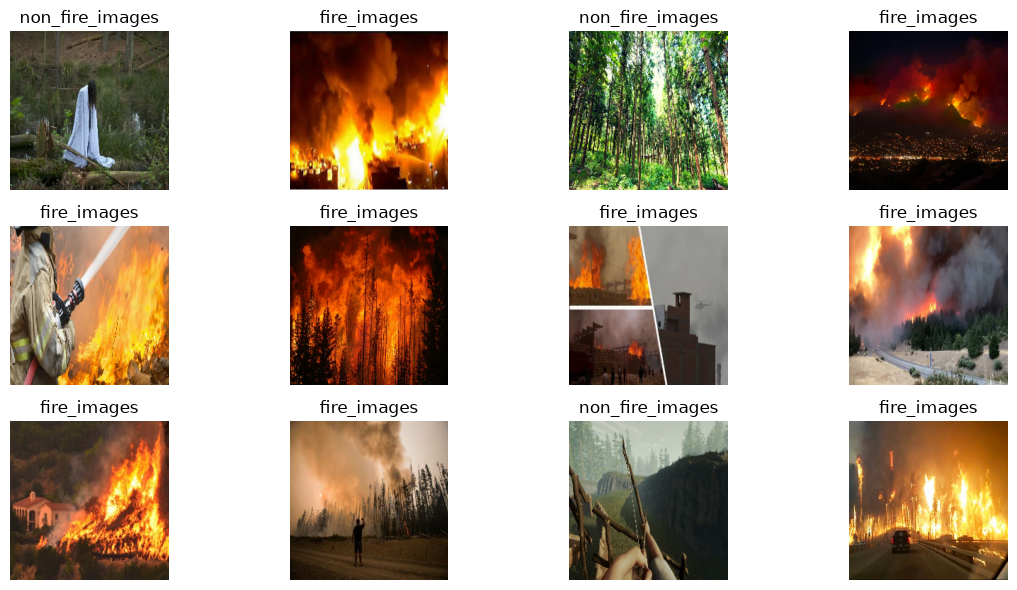

In [12]:
# Your exploration here
from collections import Counter
from PIL import Image

# 1. Class counts on disk
print("Images per class (whole dataset):")
for name in class_names_fire:
    n = len(os.listdir(os.path.join(data_dir_fire, name)))
    print(f"  {name:16s} {n:4d}")

# 2. Class counts in each split
def count_labels(ds):
    labels = np.concatenate([y.numpy() for _, y in ds])
    counts = Counter(labels)
    total = len(labels)
    return {class_names_fire[k]: f"{counts[k]} ({counts[k] / total:.0%})" for k in sorted(counts)}

print("\nTrain:", count_labels(train_raw_fire))
print("Val:  ", count_labels(val_raw_fire))
print("Test: ", count_labels(test_raw_fire))

# Count the test split a second time to check it's the same images each pass
print("Test (2nd pass):", count_labels(test_raw_fire))

# 3. Original image sizes (everything gets resized to 224x224)
sizes = Counter()
for name in class_names_fire:
    folder = os.path.join(data_dir_fire, name)
    for f in os.listdir(folder)[:100]:
        with Image.open(os.path.join(folder, f)) as img:
            sizes[img.size] += 1
print("\nMost common original sizes (first 100 per class):", sizes.most_common(5))

# 4. Sample images from each class
images, labels = next(iter(train_raw_fire))
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names_fire[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

From the dataset, I noticed that 1) the classes are imbalanced, about 3 to 1. 2) The class ratio changes from split to split. 3) The test set isn't fixed because shuffle=True is on. 4) The non-fire images are mostly still tree and forest pictures. Also, some of the fire images are strange. One is a collage of multiple fire images. I think that the non-fire images still being forests could confuse the model down the line.

Regarding how this will change my approach, I will have to keep a small sample size in mind. There are only about 45 non-fire images in each evaluation set. I also shouldn't trust accuracy alone and consider handling the imbalance of samples with class weight or model fit, so mistakes count more.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [13]:
# Preprocess the data here
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_fire = val_raw_fire.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_fire = test_raw_fire.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

images, labels = next(iter(train_fire))
print("Batch shape:", images.shape, "| min:", float(tf.reduce_min(images)), "| max:", float(tf.reduce_max(images)))

Batch shape: (32, 224, 224, 3) | min: -1.0 | max: 1.0


In [15]:
# Build your model here

base_model_fire = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights="imagenet")
base_model_fire.trainable = False  # freeze the entire base

inputs = tf.keras.Input(shape=img_size + (3,))
x = base_model_fire(inputs, training=False)  # keep BatchNorm layers in inference mode
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)  # binary task: one output = P(class 1)

model_fire = Model(inputs, outputs)
model_fire.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
# Compile your model here
model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",  # matches the single sigmoid output
    metrics=[
        "accuracy",
        # Precision/recall measure class 1, which is non_fire_images
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

## 1D — Train and Evaluate

Class weights: {0: 0.6505576208178439, 1: 2.1604938271604937}


/home/coder/Fall-2026/IT 480/Lab 1/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/5


W0000 00:00:1791155766.784993 3116265 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


22/22 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.8971 - loss: 0.3407 - precision: 0.7206 - recall: 0.9074 - val_accuracy: 0.9568 - val_loss: 0.2018 - val_precision: 0.8974 - val_recall: 0.9459
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 134s 6s/step - accuracy: 0.9543 - loss: 0.1459 - precision: 0.8495 - recall: 0.9753 - val_accuracy: 0.9568 - val_loss: 0.1229 - val_precision: 1.0000 - val_recall: 0.8235
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 108s 5s/step - accuracy: 0.9771 - loss: 0.1070 - precision: 0.9294 - recall: 0.9753 - val_accuracy: 0.9712 - val_loss: 0.0836 - val_precision: 0.9697 - val_recall: 0.9143
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9843 - loss: 0.0897 - precision: 0.9521 - recall: 0.9815 - val_accuracy: 0.9856 - val_loss: 0.0745 - val_precision: 0.9722 - val_recall: 0.9722
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.9886 - loss: 0.0779 - precision: 0.9695 - recall: 0.9815 - val_accuracy: 0.9856 - val_loss: 0.0803 - val_precision: 

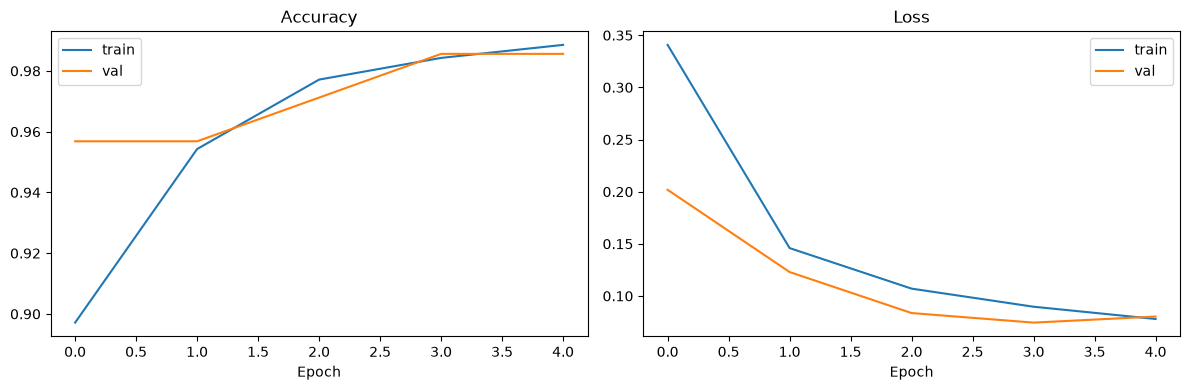

In [17]:
# Train your model here
# Class weights: make mistakes on the smaller non-fire class count more (about 3:1 imbalance)
train_labels = np.concatenate([y.numpy() for _, y in train_raw_fire])
n_total = len(train_labels)
n_non_fire = int(train_labels.sum())         # class 1 = non_fire_images
n_fire = n_total - n_non_fire                # class 0 = fire_images
class_weight_fire = {
    0: n_total / (2 * n_fire),
    1: n_total / (2 * n_non_fire),
}
print("Class weights:", class_weight_fire)

epochs = 5
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=epochs,
    class_weight=class_weight_fire,
)

# Plot training vs validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_fire.history["accuracy"], label="train")
ax1.plot(history_fire.history["val_accuracy"], label="val")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history_fire.history["loss"], label="train")
ax2.plot(history_fire.history["val_loss"], label="val")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

In [18]:
# Report validation and test accuracy here
val_results_fire = model_fire.evaluate(val_fire, return_dict=True, verbose=0)
test_results_fire = model_fire.evaluate(test_fire, return_dict=True, verbose=0)

print(f"{'':12s}{'Accuracy':>10s}{'Precision':>11s}{'Recall':>9s}{'Loss':>8s}")
for name, r in [("Validation", val_results_fire), ("Test", test_results_fire)]:
    print(f"{name:12s}{r['accuracy']:10.4f}{r['precision']:11.4f}{r['recall']:9.4f}{r['loss']:8.4f}")

# Baseline: accuracy from always guessing the majority class (fire)
print(f"\nMajority-class baseline: {n_fire / n_total:.4f}")

W0000 00:00:1791156537.382109 3116777 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


              Accuracy  Precision   Recall    Loss
Validation      0.9928     0.9737   1.0000  0.0635
Test            0.9812     0.9535   0.9762  0.0791

Majority-class baseline: 0.7686


The training run went pretty well. The validation accuracy was 0.993, and the test accuracy was 0.981. This is far above the baseline. The model also did not overfit. The training and validation curves stay close together.

## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

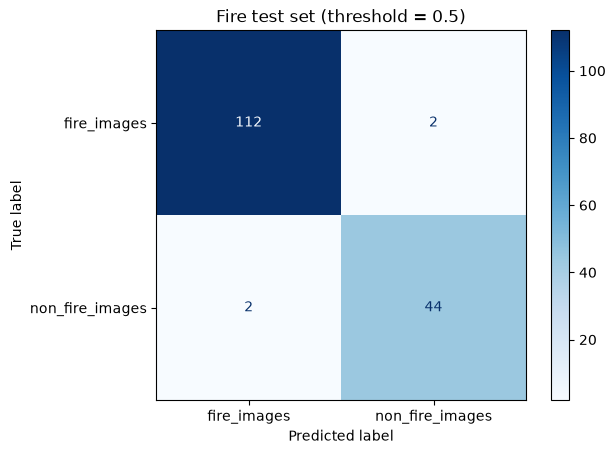

Test images: 160 | accuracy: 0.9750
Missed fires (fire predicted as non-fire): 2
False alarms (non-fire predicted as fire): 2


In [19]:
# Build your confusion matrix here
y_true_fire, y_prob_fire = [], []
for images, labels in test_fire:
    y_true_fire.append(labels.numpy())
    y_prob_fire.append(model_fire.predict(images, verbose=0).ravel())
y_true_fire = np.concatenate(y_true_fire)
y_prob_fire = np.concatenate(y_prob_fire)

threshold = 0.5
y_pred_fire = (y_prob_fire > threshold).astype(int)  # 1 = non_fire_images

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)
ConfusionMatrixDisplay(cm_fire, display_labels=class_names_fire).plot(cmap="Blues")
plt.title(f"Fire test set (threshold = {threshold})")
plt.show()

print(f"Test images: {len(y_true_fire)} | accuracy: {(y_pred_fire == y_true_fire).mean():.4f}")
print(f"Missed fires (fire predicted as non-fire): {cm_fire[0, 1]}")
print(f"False alarms (non-fire predicted as fire): {cm_fire[1, 0]}")

*Your answer:*

Recall was 0.976, meaning that about 1-2 non-fire image was labeled fire. Precision was 0.954, meaning that about 2 fire images were labeled non-fire. The confusion matrix reflects this. In this context, a fire image mislabeled as a non-fire image is definitely more costly, because it means a fire will go unnoticed. Due to this, I believe a lower threshold is very justified, as the risk of misclassifying a fire image is much more costly than the risk on misclassifying a non-fire image.


---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [5]:
#!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
#!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['SeaLake', 'Highway', 'Forest', 'HerbaceousVegetation', 'Residential', 'Pasture', 'Industrial', 'PermanentCrop', 'AnnualCrop', 'River']


In [6]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [7]:
# Preprocess the data here
# Defined again here so Part 2 still works after a kernel restart
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):
    # MobileNetV2 expects pixel values scaled from [0, 255] to [-1, 1]
    return preprocess_input(images), labels

train_sat = train_raw_sat.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_sat = val_raw_sat.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_sat = test_raw_sat.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Check: pixel range should be about -1 to 1, and labels are integers 0-9 (one per class)
images, labels = next(iter(train_sat))
print("Batch shape:", images.shape, "| min:", float(tf.reduce_min(images)), "| max:", float(tf.reduce_max(images)))
print("Number of classes:", len(class_names_sat))
print("Sample labels:", labels[:10].numpy())

W0000 00:00:1791162680.447336 3145837 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1791162680.624620 3145837 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


Batch shape: (32, 224, 224, 3) | min: -0.8577030897140503 | max: 1.0
Number of classes: 10
Sample labels: [8 7 2 2 0 6 7 1 0 1]


In [8]:
# Build your model here
num_classes_sat = len(class_names_sat)  # 10 land-use classes

# Pretrained base: ImageNet weights, no original classification head
base_model_sat = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights="imagenet")
base_model_sat.trainable = False  # freeze the entire base

inputs = tf.keras.Input(shape=img_size + (3,))
x = base_model_sat(inputs, training=False)  # keep BatchNorm layers in inference mode
x = GlobalAveragePooling2D()(x)
# Multi-class task: one output per class, softmax turns them into probabilities that sum to 1
outputs = Dense(num_classes_sat, activation="softmax")(x)

model_sat = Model(inputs, outputs)
model_sat.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile your model here
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 2C — Train and Evaluate

Epoch 1/3


/home/coder/Fall-2026/IT 480/Lab 1/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1791162736.865076 3146013 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1791162737.037743 3146013 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1791162737.044173 3145641 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.


591/591 ━━━━━━━━━━━━━━━━━━━━ 1716s 3s/step - accuracy: 0.8782 - loss: 0.3755 - val_accuracy: 0.9279 - val_loss: 0.2255
Epoch 2/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 1669s 3s/step - accuracy: 0.9342 - loss: 0.1939 - val_accuracy: 0.9371 - val_loss: 0.1920
Epoch 3/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 1580s 3s/step - accuracy: 0.9472 - loss: 0.1583 - val_accuracy: 0.9386 - val_loss: 0.1815


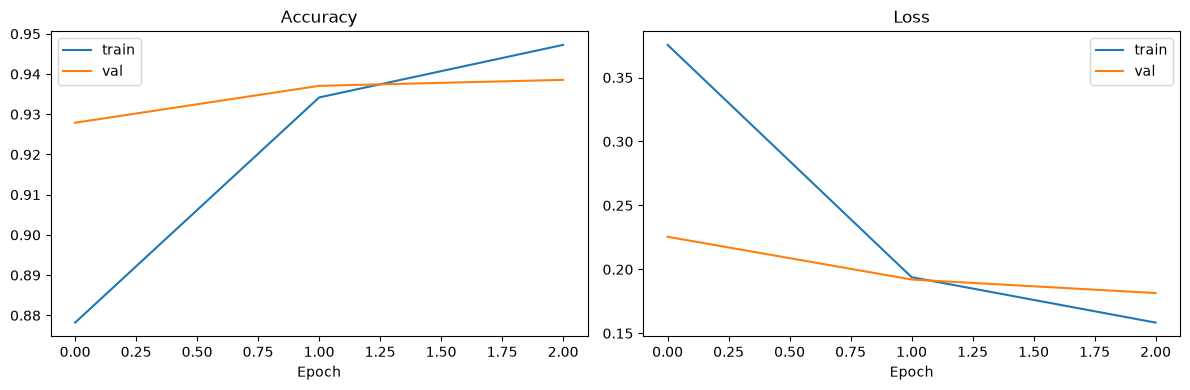

In [10]:
# Train your model here
epochs_sat = 3

backup_sat = tf.keras.callbacks.BackupAndRestore(backup_dir="/tmp/eurosat_backup")

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=epochs_sat,
    callbacks=[backup_sat],
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_sat.history["accuracy"], label="train")
ax1.plot(history_sat.history["val_accuracy"], label="val")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history_sat.history["loss"], label="train")
ax2.plot(history_sat.history["val_loss"], label="val")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

In [11]:
# Report validation and test accuracy here
val_results_sat = model_sat.evaluate(val_sat, return_dict=True, verbose=0)
test_results_sat = model_sat.evaluate(test_sat, return_dict=True, verbose=0)

print(f"{'':12s}{'Accuracy':>10s}{'Loss':>8s}")
for name, r in [("Validation", val_results_sat), ("Test", test_results_sat)]:
    print(f"{name:12s}{r['accuracy']:10.4f}{r['loss']:8.4f}")

# Baselines: random guessing across 10 classes, and always guessing the largest class
class_counts_sat = {name: len(os.listdir(os.path.join(data_dir_sat, name))) for name in class_names_sat}
print(f"\nRandom-guess baseline:   {1 / len(class_names_sat):.4f}")
print(f"Majority-class baseline: {max(class_counts_sat.values()) / sum(class_counts_sat.values()):.4f}")

              Accuracy    Loss
Validation      0.9386  0.1827
Test            0.9363  0.1827

Random-guess baseline:   0.1000
Majority-class baseline: 0.1111


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

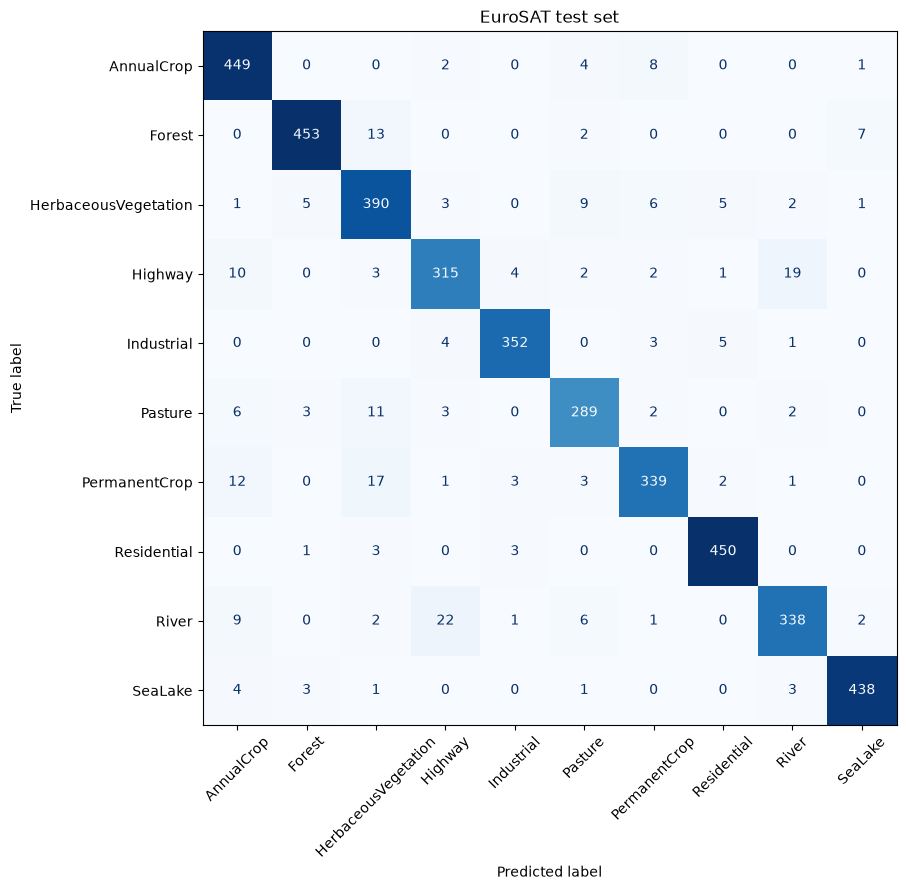

Test images: 4064 | accuracy: 0.9382

Per-class accuracy:
  Highway                0.885
  River                  0.887
  PermanentCrop          0.897
  Pasture                0.915
  HerbaceousVegetation   0.924
  Forest                 0.954
  Industrial             0.964
  AnnualCrop             0.968
  SeaLake                0.973
  Residential            0.985

Most common confusions (true -> predicted):
  River                  -> Highway                22
  Highway                -> River                  19
  PermanentCrop          -> HerbaceousVegetation   17
  Forest                 -> HerbaceousVegetation   13
  PermanentCrop          -> AnnualCrop             12
  Pasture                -> HerbaceousVegetation   11


In [ ]:
# Build your confusion matrix here
y_true_sat, y_pred_sat = [], []
for images, labels in test_sat:
    y_true_sat.append(labels.numpy())
    probs = model_sat.predict(images, verbose=0)
    y_pred_sat.append(np.argmax(probs, axis=1))  # predicted class = highest softmax probability
y_true_sat = np.concatenate(y_true_sat)
y_pred_sat = np.concatenate(y_pred_sat)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm_sat, display_labels=class_names_sat).plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)
plt.title("EuroSAT test set")
plt.tight_layout()
plt.show()

print(f"Test images: {len(y_true_sat)} | accuracy: {(y_pred_sat == y_true_sat).mean():.4f}")

# Per-class accuracy (recall): fraction of each true class predicted correctly
print("\nPer-class accuracy:")
per_class = cm_sat.diagonal() / cm_sat.sum(axis=1)
for i in np.argsort(per_class):
    print(f"  {class_names_sat[i]:22s} {per_class[i]:.3f}")

# Most common mistakes (off-diagonal cells)
print("\nMost common confusions (true -> predicted):")
off_diag = cm_sat.copy()
np.fill_diagonal(off_diag, 0)
for idx in np.argsort(off_diag, axis=None)[::-1][:6]:
    t, p = np.unravel_index(idx, off_diag.shape)
    print(f"  {class_names_sat[t]:22s} -> {class_names_sat[p]:22s} {off_diag[t, p]}")

*Your answer:*

The land classes that are confused most often are River/Highway, PermamentCrop/HerbaceusVegetation, Forest/HerbaceousVegetation, PermanentCrop/AnnualCrop, and Pasture/HerbaceousVegetation. These confusions make perfect sense because of the visual similarities in the satellite images. Rivers and Highways are both long, bending structures. Permanent crops, pastures, forests, and herbaceous vegetation are all similar areas filled with plant life. 

---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9928 | 0.9386 |
| Test Accuracy | 0.9812 | 0.9363 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. The first dataset is definitely a closer match to the original training. The pictures of forest fires seem to all be taken from the ground, with some looking like they could have possibly been taken from a helicopter or something similar. This results in pictures that resemble the original photos much more. This is also supported by the accuracy difference between the first and second datasets, with the model performing better on the first.

2. For the fire dataset, there realistically isn't much room to improve. The testing accuracy, at 98.1%, is already near the ceiling. There are not many mistakes left to fix. The EuroSAT dataset has more room to improve. The testing accuracy was 93.6%, which suggests that freezing features are limiting it. Since ImageNet never taught the model what fields, rivers, or highways look like from above, the features don't fit as well. The confusion matrix points to the same cause. Fine tuning would be a good solution to improve performance.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

1. Yes, the imbalance of the Fire datasets images meant always guessing fire would be correct about 3/4 of the time. To counter this, I used class weights, precision and recall, and a confusion matrix instead of relying on accuracy alone. 
2. Part 1 used a single Dense(1) output with sigmoid and binary crossentropy because the fire detection was a simple yes/no problem. Part 2 used Dense(10) with softmax and sparse categorical crossentropy because each EuroSAT image belongs to 1 of 10 classes and its labels are 0-9. 
3. A pretrained model's usefulness definitely depends on how well its original training matches the task. The test accuracy on the fire images got up to 98% on ground level photos, but the test accuracy on the overhead images got up to only ~94%. Even though EuroSAT had much more training data, it performed worse because the original training didn't match the task well.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.